In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/xgboost.pkl")
print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
df = pd.read_csv("../data/processed/train_smote.csv")
X = df.drop("fraud_bool", axis=1)
feature_names = X.columns
print("Total Features:", len(feature_names))

Total Features: 47


In [4]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(20)

,Feature,Importance
22,keep_alive_session,0.149359
18,has_other_cards,0.132721
39,housing_status_4,0.107136
44,device_os_2,0.089188
38,housing_status_3,0.074979
15,phone_home_valid,0.056748
36,housing_status_1,0.047569
37,housing_status_2,0.045072
30,employment_status_1,0.040477
4,customer_age,0.035334


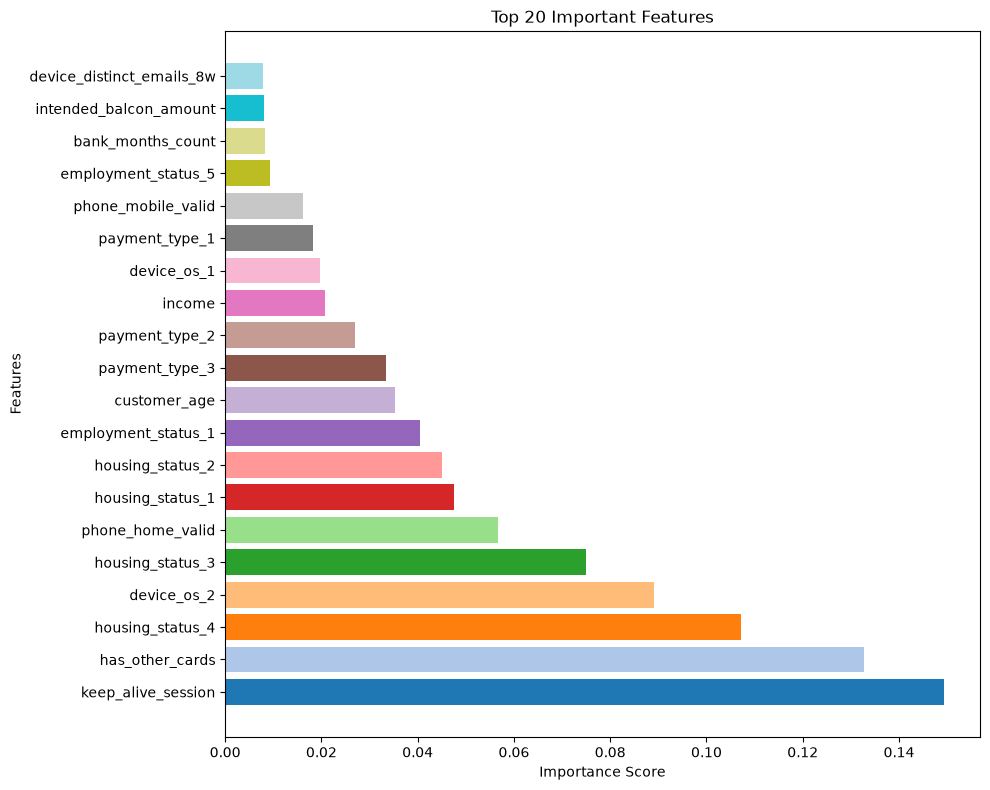

In [7]:
plt.figure(figsize=(10,8))
top20 = importance.head(20)
colors = plt.cm.tab20(np.linspace(0, 1, len(top20)))
plt.barh(
    top20["Feature"],
    top20["Importance"],
    color=colors
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [8]:
importance.to_csv("../data/processed/feature_importance.csv",index=False)
print("Feature Importance Saved Successfully")

Feature Importance Saved Successfully


In [9]:
top10 = importance.head(10)
print("Top 10 Fraud Predictors")
top10

Top 10 Fraud Predictors


,Feature,Importance
22,keep_alive_session,0.149359
18,has_other_cards,0.132721
39,housing_status_4,0.107136
44,device_os_2,0.089188
38,housing_status_3,0.074979
15,phone_home_valid,0.056748
36,housing_status_1,0.047569
37,housing_status_2,0.045072
30,employment_status_1,0.040477
4,customer_age,0.035334


In [10]:
for i, row in top10.iterrows():
    print(
        f"{row['Feature']} : Importance = {row['Importance']:.4f}"
    )

keep_alive_session : Importance = 0.1494
has_other_cards : Importance = 0.1327
housing_status_4 : Importance = 0.1071
device_os_2 : Importance = 0.0892
housing_status_3 : Importance = 0.0750
phone_home_valid : Importance = 0.0567
housing_status_1 : Importance = 0.0476
housing_status_2 : Importance = 0.0451
employment_status_1 : Importance = 0.0405
customer_age : Importance = 0.0353


In [11]:
top10.to_csv("../data/processed/top10_fraud_features.csv",index=False)
print("Top 10 Features Saved")

Top 10 Features Saved


# Notebook 19 Summary

- Loaded the best-performing fraud detection model (XGBoost).
- Extracted feature importance scores.
- Identified the most influential fraud indicators.
- Visualized the top 20 important features.
- Ranked fraud predictors based on contribution to model decisions.
- Saved feature importance results for reporting and deployment.
- Improved model transparency and interpretability.